In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configurable paths

# Promoter-level chec-seq signal (sumprom) for Human TFs
sumprom_chec_glob = "sumproms/*gz"

# Promoter-level chec-seq signal for yeast TFs (see manuscript)
yeast_tf_sumprom_glob = '../Yeast_Native_TF_outfiles/results/sumproms/*.gz'

## Imports

In [3]:
import numpy as np
import pandas as pd

import glob

from scipy.stats import zscore

import matplotlib.pyplot as plt

In [4]:
sumprom_chec_files = glob.glob(sumprom_chec_glob)
sumprom_all = pd.concat([pd.read_parquet(x) for x in sumprom_chec_files], axis=1)

corr_cutoff = 0.895

def filter_reproducible(sumprom_all: pd.DataFrame, cutoff) -> pd.DataFrame:
    df = sumprom_all.copy()
    groups = pd.Series(df.columns, index=df.columns).str.rsplit("_", n=2).str[0]
    
    keep = []
    for _, members in groups.groupby(groups).groups.items():
        if len(members) < 2:
            continue
        corr = df[members].corr()
        np.fill_diagonal(corr.values, np.nan)
        max_corrs = corr.max(axis=1)
        reproducible = max_corrs[max_corrs >= cutoff].index.tolist()
        keep.extend(reproducible)
    return df[keep]

sumprom_filtered = filter_reproducible(sumprom_all, cutoff=corr_cutoff)
cols = sumprom_filtered.columns.astype(str)
base_sumprom = cols.str.rsplit('_', n=2).str[0]
sumprom = sumprom_filtered.T.groupby(base_sumprom).mean().T
sumprom_z = sumprom.apply(zscore)

In [5]:
native_tf_sumprom_files = glob.glob(yeast_tf_sumprom_glob)
native_tf_sumprom = pd.concat([pd.read_parquet(x) for x in native_tf_sumprom_files], axis=1)
native_tf_sumprom_z = native_tf_sumprom.apply(zscore)

In [6]:
combined_sumprom_z = pd.concat([sumprom_z, native_tf_sumprom_z], axis=1)

In [7]:
def darken_color(color, factor=0.7):
    """Return a slightly darker version of an RGBA color."""
    r, g, b, a = color
    return (r * factor, g * factor, b * factor, a)

def plot_samples_scatter(
    df,
    sample_x: str,
    sample_y: str,
    point_size: int = 20,
    figsize = (2.7, 3.8),
    leg_x = 0.58,
    leg_y = 0.12
):
    x = df[sample_x].values
    y = df[sample_y].values

    c = (0.40, 0.62, 0.94, 0.88)
    edge_c = darken_color(c, 0.6)

    r = float(np.corrcoef(x, y)[0, 1])

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        x, y,
        s=point_size,
        color=c,
        edgecolors=edge_c,
        linewidths=0.4,
        alpha=c[3],
    )

    all_vals = np.concatenate([x, y])
    vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)
    pad = 0.08 * (vmax - vmin if np.isfinite(vmax - vmin) else 1.0)
    ax.set_xlim(vmin -0.8, vmax + pad)
    ax.set_ylim(vmin -0.8, 13)

    ticks = np.arange(0, np.ceil(vmax / 5) * 5 + 1, 5)
    ax.set_xticks(ticks[ticks <= ax.get_xlim()[1]])
    ax.set_yticks(ticks[ticks <= ax.get_ylim()[1]])

    ax.text(
        leg_x, leg_y,
        f"r = {r:.2f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=13,
        bbox=dict(facecolor="white", boxstyle="round,pad=0.25"),
    )

    ax.set_xlabel(f"{sample_x} z-score", fontsize=14, labelpad=3)
    ax.set_ylabel(f"{sample_y} z-score", fontsize=14, labelpad=-2)
    # ax.set_title(f"{sample_x} vs {sample_y}", fontsize=14)

    plt.tight_layout()
    plt.show()

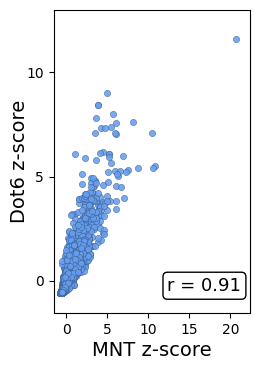

In [8]:
plot_samples_scatter(
    combined_sumprom_z,
    sample_x="MNT",
    sample_y="Dot6")